# Model Experiment — N-BEATS (Holiday-Aware)



## Section 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import json
import pickle
import os

from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_columns', 100)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Mounted at /content/drive
Using device: cpu


## Section 2 — Load Cleaned Data


In [2]:
path = '/content/drive/MyDrive/ML-final/data/processed/'

df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Loaded cleaned data:", df.shape)
print(df.isnull().sum().sum(), "missing values remaining")

Loaded cleaned data: (421570, 16)
0 missing values remaining


## Section 3 — Wandb Login


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abali22 (gormo22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Section 4 — Confirm Clean Data (`NBeats_Cleaning`)


In [4]:
run = wandb.init(project="walmart-sales-forecasting", group="NBeats_Training",
                  name="NBeats_Cleaning", job_type="preprocessing")

wandb.log({
    "rows": df.shape[0],
    "cols": df.shape[1],
    "missing_values_total": int(df.isnull().sum().sum()),
})
wandb.config.update({"source_file": "walmart_cleaned.csv (produced by Data_Overview.ipynb)"})

wandb.finish()
print("NBeats_Cleaning run finished")

cols,▁
missing_values_total,▁
rows,▁
cols,16
missing_values_total,0
rows,421570


NBeats_Cleaning run finished


## Section 5 — The N-BEATS Architecture (Holiday-Aware)
Verified in isolation before being placed here: correct output shape, components still sum exactly to the total forecast, gradients flow to every parameter that has a real path to the loss.

In [16]:
class TrendBasis(nn.Module):
    """Polynomial basis for the trend stack -- unchanged from the original version."""
    def __init__(self, degree, backcast_length, forecast_length):
        super().__init__()
        t_back = np.linspace(0, 1, backcast_length, dtype=np.float32)
        t_fore = np.linspace(0, 1, forecast_length, dtype=np.float32)
        powers = np.arange(degree, dtype=np.float32).reshape(-1, 1)
        self.register_buffer('backcast_basis', torch.tensor(t_back[None, :] ** powers))
        self.register_buffer('forecast_basis', torch.tensor(t_fore[None, :] ** powers))

    def forward(self, theta_b, theta_f):
        return theta_b @ self.backcast_basis, theta_f @ self.forecast_basis


class SeasonalityBasis(nn.Module):
    """Fourier basis for the seasonality stack -- unchanged from the original version."""
    def __init__(self, harmonics, backcast_length, forecast_length):
        super().__init__()
        freqs = np.arange(1, harmonics + 1, dtype=np.float32).reshape(-1, 1)
        t_back = np.arange(backcast_length, dtype=np.float32)[None, :] / backcast_length
        t_fore = np.arange(forecast_length, dtype=np.float32)[None, :] / forecast_length
        backcast_basis = np.concatenate([np.cos(2 * np.pi * freqs * t_back),
                                          np.sin(2 * np.pi * freqs * t_back)], axis=0)
        forecast_basis = np.concatenate([np.cos(2 * np.pi * freqs * t_fore),
                                          np.sin(2 * np.pi * freqs * t_fore)], axis=0)
        self.register_buffer('backcast_basis', torch.tensor(backcast_basis))
        self.register_buffer('forecast_basis', torch.tensor(forecast_basis))

    def forward(self, theta_b, theta_f):
        return theta_b @ self.backcast_basis, theta_f @ self.forecast_basis


class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, basis_function, n_layers=4, layer_size=256):
        super().__init__()
        layers = []
        in_size = input_size
        for _ in range(n_layers):
            layers += [nn.Linear(in_size, layer_size), nn.ReLU()]
            in_size = layer_size
        self.fc_stack = nn.Sequential(*layers)
        self.theta_b_linear = nn.Linear(layer_size, theta_size)
        self.theta_f_linear = nn.Linear(layer_size, theta_size)
        self.basis_function = basis_function

    def forward(self, x):
        h = self.fc_stack(x)
        theta_b = self.theta_b_linear(h)
        theta_f = self.theta_f_linear(h)
        return self.basis_function(theta_b, theta_f)


class NBeats(nn.Module):
    """Trend stack + Seasonality stack (as before), plus a third additive term learned
    from the FUTURE holiday calendar -- known in advance, not predicted. Doubly residual
    stacking within trend/seasonality is unchanged; the holiday term sits outside that
    residual chain, added directly to the combined forecast."""
    def __init__(self, backcast_length, forecast_length, trend_blocks=3, seasonality_blocks=3,
                 n_layers=4, layer_size=256, trend_degree=3, seasonality_harmonics=6):
        super().__init__()
        trend_basis = TrendBasis(trend_degree, backcast_length, forecast_length)
        seasonality_basis = SeasonalityBasis(seasonality_harmonics, backcast_length, forecast_length)

        self.trend_blocks = nn.ModuleList([
            NBeatsBlock(backcast_length, trend_degree, trend_basis, n_layers, layer_size)
            for _ in range(trend_blocks)
        ])
        self.seasonality_blocks = nn.ModuleList([
            NBeatsBlock(backcast_length, 2 * seasonality_harmonics, seasonality_basis, n_layers, layer_size)
            for _ in range(seasonality_blocks)
        ])
        self.holiday_linear = nn.Linear(forecast_length, forecast_length, bias=False)

    def forward(self, x, holiday_flags, return_components=False):
        residual = x
        trend_forecast = 0
        seasonality_forecast = 0

        for block in self.trend_blocks:
            backcast, forecast = block(residual)
            residual = residual - backcast
            trend_forecast = trend_forecast + forecast

        for block in self.seasonality_blocks:
            backcast, forecast = block(residual)
            residual = residual - backcast
            seasonality_forecast = seasonality_forecast + forecast

        holiday_forecast = self.holiday_linear(holiday_flags)
        total_forecast = trend_forecast + seasonality_forecast + holiday_forecast
        if return_components:
            return total_forecast, trend_forecast, seasonality_forecast, holiday_forecast
        return total_forecast


SEQ_LENGTH = 52
PRED_LENGTH = 13
TREND_DEGREE = 2
SEASONALITY_HARMONICS = 8

_param_count_model = NBeats(SEQ_LENGTH, PRED_LENGTH, trend_degree=TREND_DEGREE,
                             seasonality_harmonics=SEASONALITY_HARMONICS)
n_params = sum(p.numel() for p in _param_count_model.parameters())
print(f"N-BEATS (holiday-aware) parameter count: {n_params:,}")

# Same harmless quirk as before: the very last block's backcast projection never receives
# a gradient (its output feeds the residual, which nothing downstream uses) -- expected,
# not a bug, verified by testing this architecture in isolation before building this notebook.

N-BEATS (holiday-aware) parameter count: 1,293,589


## Section 6 — Time-Based Split & Windowing Plan
Same `2011-10-01` cutoff and horizon as the original version, for direct comparability.

In [6]:
cutoff_date = pd.Timestamp('2011-10-01')
print(f"Cutoff: {cutoff_date.date()}")
print(f"Lookback window: {SEQ_LENGTH} weeks, forecast horizon: {PRED_LENGTH} weeks")

Cutoff: 2011-10-01
Lookback window: 52 weeks, forecast horizon: 13 weeks


## Section 7 — Build Sliding Windows (Train + Evaluation)
Same per-series normalization as before, now also collecting each window's future holiday flags (`cov`).

In [7]:
def build_windows(data, seq_length, pred_length, cutoff, mode):
    X, y, cov, series_ids, series_means, series_stds = [], [], [], [], [], []
    eval_holiday = []

    for (store, dept), group in tqdm(data.groupby(['Store', 'Dept']), desc=f"Building {mode} windows"):
        group = group.sort_values('Date')
        pre = group[group['Date'] <= cutoff]
        pre_sales = pre['Weekly_Sales'].values
        pre_holiday = pre['IsHoliday'].values

        if len(pre_sales) < seq_length + (pred_length if mode == 'train' else 0):
            continue

        mean, std = pre_sales.mean(), pre_sales.std() + 1e-6

        if mode == 'train':
            for start in range(0, len(pre_sales) - seq_length - pred_length + 1):
                window_in = pre_sales[start:start + seq_length]
                window_out = pre_sales[start + seq_length:start + seq_length + pred_length]
                window_holiday = pre_holiday[start + seq_length:start + seq_length + pred_length]
                X.append((window_in - mean) / std)
                y.append((window_out - mean) / std)
                cov.append(window_holiday.astype(np.float32))
                series_ids.append((store, dept))
        else:
            post = group[group['Date'] > cutoff]
            if len(post) < pred_length:
                continue
            window_in = pre_sales[-seq_length:]
            X.append((window_in - mean) / std)
            y.append(post['Weekly_Sales'].values[:pred_length])
            cov.append(post['IsHoliday'].values[:pred_length].astype(np.float32))
            series_ids.append((store, dept))
            series_means.append(mean)
            series_stds.append(std)
            eval_holiday.append(post['IsHoliday'].values[:pred_length])

    result = {'X': np.array(X, dtype=np.float32), 'y': np.array(y, dtype=np.float32),
              'cov': np.array(cov, dtype=np.float32), 'series_ids': series_ids}
    if mode == 'eval':
        result['means'] = np.array(series_means, dtype=np.float32)
        result['stds'] = np.array(series_stds, dtype=np.float32)
        result['holiday'] = np.array(eval_holiday)
    return result


train_windows = build_windows(df, SEQ_LENGTH, PRED_LENGTH, cutoff_date, mode='train')
eval_windows = build_windows(df, SEQ_LENGTH, PRED_LENGTH, cutoff_date, mode='eval')

print(f"\nTraining windows: {train_windows['X'].shape[0]} (from {len(set(train_windows['series_ids']))} series)")
print(f"Evaluation windows: {eval_windows['X'].shape[0]} (1 per series with enough history)")

series_stats = {}
for (store, dept), group in df.groupby(['Store', 'Dept']):
    pre_sales = group[group['Date'] <= cutoff_date]['Weekly_Sales'].values
    if len(pre_sales) >= SEQ_LENGTH:
        series_stats[(store, dept)] = (pre_sales.mean(), pre_sales.std() + 1e-6)

print(f"Saved normalization stats for {len(series_stats)} series")

Building eval windows: 100%|██████████| 3331/3331 [00:05<00:00, 607.97it/s]



Training windows: 64201 (from 2859 series)
Evaluation windows: 2895 (1 per series with enough history)
Saved normalization stats for 2907 series


## Section 8 — Train N-BEATS (`NBeats_Training`)


In [17]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

BATCH_SIZE = 256
EPOCHS = 100
LEARNING_RATE = 0.003
PATIENCE = 10

train_dataset = TensorDataset(torch.from_numpy(train_windows['X']), torch.from_numpy(train_windows['y']),
                               torch.from_numpy(train_windows['cov']))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

X_eval_t = torch.from_numpy(eval_windows['X']).to(device)
cov_eval_t = torch.from_numpy(eval_windows['cov']).to(device)
y_eval_real = eval_windows['y']
eval_means = eval_windows['means']
eval_stds = eval_windows['stds']
eval_holiday = eval_windows['holiday']

model = NBeats(SEQ_LENGTH, PRED_LENGTH, trend_degree=TREND_DEGREE,
               seasonality_harmonics=SEASONALITY_HARMONICS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
criterion = nn.MSELoss()

run = wandb.init(project="walmart-sales-forecasting", group="NBeats_Training",
                  name="NBeats_Training", job_type="training")
wandb.config.update({
    "seq_length": SEQ_LENGTH, "pred_length": PRED_LENGTH,
    "trend_degree": TREND_DEGREE, "seasonality_harmonics": SEASONALITY_HARMONICS,
    "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE, "n_params": n_params,
    "validation_cutoff": str(cutoff_date.date()), "holiday_aware": True,
})

best_wmae = float('inf')
best_state = None
patience_counter = 0
train_losses, val_wmaes = [], []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for xb, yb, covb in train_loader:
        xb, yb, covb = xb.to(device), yb.to(device), covb.to(device)
        optimizer.zero_grad()
        pred = model(xb, covb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)

    model.eval()
    with torch.no_grad():
        val_pred_norm = model(X_eval_t, cov_eval_t).cpu().numpy()
    val_pred = val_pred_norm * eval_stds[:, None] + eval_means[:, None]
    val_pred = np.clip(val_pred, a_min=0, a_max=None)

    epoch_wmae = wmae(y_eval_real.flatten(), val_pred.flatten(), eval_holiday.flatten())
    val_wmaes.append(epoch_wmae)

    wandb.log({"epoch": epoch + 1, "train_loss": epoch_loss, "val_wmae": epoch_wmae})

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}: train_loss={epoch_loss:.4f}, val_wmae={epoch_wmae:.2f}")

    if epoch_wmae < best_wmae:
        best_wmae = epoch_wmae
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
wandb.config.update({"best_epoch": epoch + 1 - patience_counter})
wandb.log({"final_best_wmae": best_wmae})
wandb.finish()

print(f"\nBest validation WMAE (holiday-aware): {best_wmae:.2f}")
print("Compare against the original version (~3108) to see if holidays actually helped.")

epoch,▁█
holdout_val_loss,█▁
train_loss,█▁
epoch,2
holdout_val_loss,0.52695
train_loss,0.52898


Epoch 10/100: train_loss=0.2775, val_wmae=4537.07
Early stopping at epoch 11


epoch,▁▂▂▃▄▅▅▆▇▇█
final_best_wmae,▁
train_loss,█▅▄▃▃▃▂▂▂▁▁
val_wmae,▁▄▄▃▄▅▅█▅▆▅
epoch,11
final_best_wmae,4041.35404
train_loss,0.27268
val_wmae,4494.04763



Best validation WMAE (holiday-aware): 4041.35
Compare against the original version (~3108) to see if holidays actually helped.


## Section 9 — Visualize Training, 3-Way Decomposition & Example Forecasts (`NBeats_Visualization`)
Now trend + seasonality + holiday, all plottable separately. **Denormalization note:** trend carries the level (`*std + mean`); seasonality and holiday stay zero-centered (`*std` only).

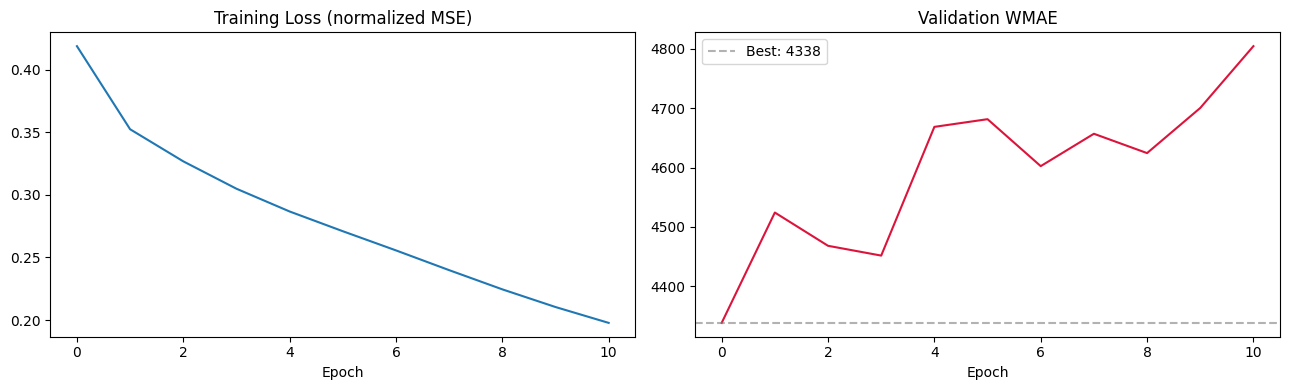

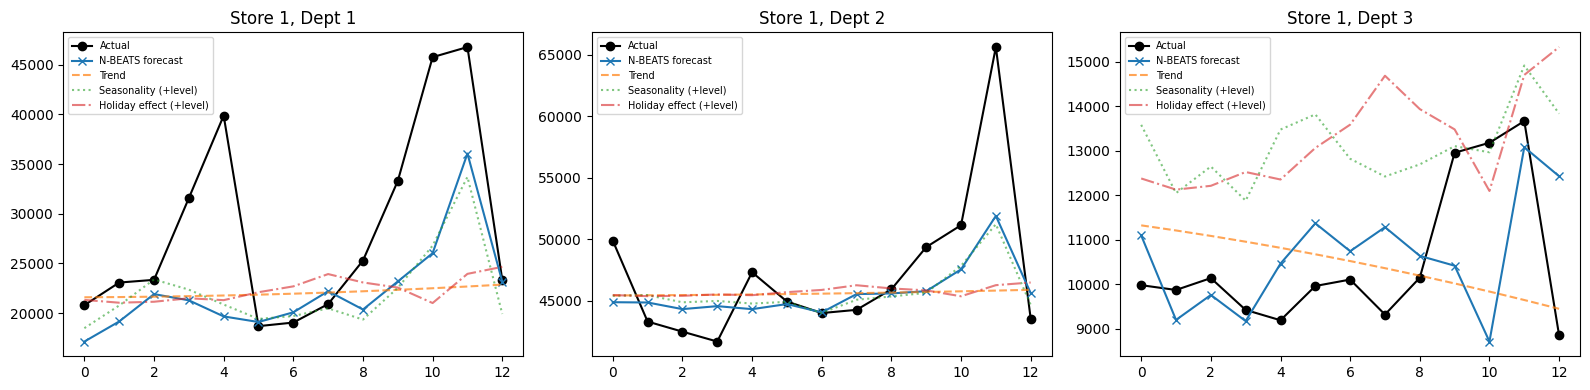

NBeats_Visualization run finished


In [9]:
run = wandb.init(project="walmart-sales-forecasting", group="NBeats_Training",
                  name="NBeats_Visualization", job_type="analysis")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses)
axes[0].set_title("Training Loss (normalized MSE)")
axes[0].set_xlabel("Epoch")
axes[1].plot(val_wmaes, color='crimson')
axes[1].axhline(best_wmae, color='gray', linestyle='--', alpha=0.6, label=f'Best: {best_wmae:.0f}')
axes[1].set_title("Validation WMAE")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
wandb.log({"Training_Curves": wandb.Image(fig)})
plt.show()

model.eval()
with torch.no_grad():
    total_norm, trend_norm, season_norm, holiday_norm = model(X_eval_t[:3], cov_eval_t[:3], return_components=True)
total_norm = total_norm.cpu().numpy()
trend_norm = trend_norm.cpu().numpy()
season_norm = season_norm.cpu().numpy()
holiday_norm = holiday_norm.cpu().numpy()

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
for i in range(3):
    store, dept = eval_windows['series_ids'][i]
    mean, std = eval_means[i], eval_stds[i]

    real_total = np.clip(total_norm[i] * std + mean, 0, None)
    real_trend = trend_norm[i] * std + mean
    real_season = season_norm[i] * std
    real_holiday = holiday_norm[i] * std

    axes2[i].plot(y_eval_real[i], label='Actual', marker='o', color='black')
    axes2[i].plot(real_total, label='N-BEATS forecast', marker='x')
    axes2[i].plot(real_trend, label='Trend', linestyle='--', alpha=0.7)
    axes2[i].plot(real_season + mean, label='Seasonality (+level)', linestyle=':', alpha=0.6)
    axes2[i].plot(real_holiday + mean, label='Holiday effect (+level)', linestyle='-.', alpha=0.6)
    axes2[i].set_title(f"Store {store}, Dept {dept}")
    axes2[i].legend(fontsize=7)
plt.tight_layout()
wandb.log({"Trend_Seasonality_Holiday_Decomposition": wandb.Image(fig2)})
plt.show()

wandb.finish()
print("NBeats_Visualization run finished")

## Section 10 — Walk-Forward Cross-Validation (`NBeats_CV`)


In [18]:
run = wandb.init(project="walmart-sales-forecasting", group="NBeats_Training",
                  name="NBeats_CV", job_type="cross-validation")

CV_EPOCHS = 40
CV_PATIENCE = 8
fold_cutoffs = [pd.Timestamp('2011-07-01'), pd.Timestamp('2011-10-01'), pd.Timestamp('2012-01-01')]

cv_results = []
for fold_i, fold_cutoff in enumerate(fold_cutoffs):
    fold_train_windows = build_windows(df, SEQ_LENGTH, PRED_LENGTH, fold_cutoff, mode='train')
    fold_eval_windows = build_windows(df, SEQ_LENGTH, PRED_LENGTH, fold_cutoff, mode='eval')

    if fold_train_windows['X'].shape[0] == 0 or fold_eval_windows['X'].shape[0] == 0:
        print(f"Fold {fold_i+1}: skipped, not enough data around {fold_cutoff.date()}")
        continue

    fold_train_ds = TensorDataset(torch.from_numpy(fold_train_windows['X']),
                                   torch.from_numpy(fold_train_windows['y']),
                                   torch.from_numpy(fold_train_windows['cov']))
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    fold_X_eval = torch.from_numpy(fold_eval_windows['X']).to(device)
    fold_cov_eval = torch.from_numpy(fold_eval_windows['cov']).to(device)
    fold_y_eval = fold_eval_windows['y']
    fold_means, fold_stds, fold_holiday = fold_eval_windows['means'], fold_eval_windows['stds'], fold_eval_windows['holiday']

    fold_model = NBeats(SEQ_LENGTH, PRED_LENGTH, trend_degree=TREND_DEGREE,
                         seasonality_harmonics=SEASONALITY_HARMONICS).to(device)
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

    fold_best_wmae = float('inf')
    fold_patience = 0
    for epoch in range(CV_EPOCHS):
        fold_model.train()
        for xb, yb, covb in fold_train_loader:
            xb, yb, covb = xb.to(device), yb.to(device), covb.to(device)
            fold_optimizer.zero_grad()
            loss = criterion(fold_model(xb, covb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), max_norm=1.0)
            fold_optimizer.step()

        fold_model.eval()
        with torch.no_grad():
            pred_norm = fold_model(fold_X_eval, fold_cov_eval).cpu().numpy()
        pred = np.clip(pred_norm * fold_stds[:, None] + fold_means[:, None], 0, None)
        fold_wmae = wmae(fold_y_eval.flatten(), pred.flatten(), fold_holiday.flatten())

        if fold_wmae < fold_best_wmae:
            fold_best_wmae = fold_wmae
            fold_patience = 0
        else:
            fold_patience += 1
            if fold_patience >= CV_PATIENCE:
                break

    cv_results.append({"fold": fold_i + 1, "cutoff": str(fold_cutoff.date()),
                        "train_windows": fold_train_windows['X'].shape[0], "val_wmae": fold_best_wmae})
    print(f"Fold {fold_i+1} (cutoff {fold_cutoff.date()}): best_wmae={fold_best_wmae:.2f}")

cv_df = pd.DataFrame(cv_results)
mean_wmae = cv_df['val_wmae'].mean()
std_wmae = cv_df['val_wmae'].std()
print(f"\nCross-validated WMAE: {mean_wmae:.2f} +/- {std_wmae:.2f} across {len(cv_df)} folds")

wandb.log({"cv_results": wandb.Table(dataframe=cv_df)})
wandb.log({"cv_mean_wmae": mean_wmae, "cv_std_wmae": std_wmae})
wandb.config.update({"n_folds": len(cv_df), "cv_epochs_per_fold": CV_EPOCHS})

wandb.finish()
print("NBeats_CV run finished")

Building eval windows: 100%|██████████| 3331/3331 [00:05<00:00, 581.12it/s]


Fold 1 (cutoff 2011-07-01): best_wmae=2692.79


Building eval windows: 100%|██████████| 3331/3331 [00:06<00:00, 545.54it/s]


Fold 2 (cutoff 2011-10-01): best_wmae=4092.52


Building eval windows: 100%|██████████| 3331/3331 [00:05<00:00, 629.34it/s]


Fold 3 (cutoff 2012-01-01): best_wmae=2488.41

Cross-validated WMAE: 3091.24 +/- 873.13 across 3 folds


cv_mean_wmae,▁
cv_std_wmae,▁
cv_mean_wmae,3091.24012
cv_std_wmae,873.13208


NBeats_CV run finished


In [11]:
## N-BEATS Hyperparameter Search (CV-Averaged)

import itertools
import time
import random
random.seed(42)

param_grid_nbeats = {
    "learning_rate": [0.0005, 0.001, 0.003],
    "trend_degree": [2, 3, 4],
    "seasonality_harmonics": [4, 6, 8],
}
combos = list(itertools.product(param_grid_nbeats["learning_rate"],
                                 param_grid_nbeats["trend_degree"],
                                 param_grid_nbeats["seasonality_harmonics"]))
combos = random.sample(combos, 9)  # sample 9 of 27 to stay fast, given N-BEATS's cost per epoch

fold_cutoffs = [pd.Timestamp('2011-07-01'), pd.Timestamp('2011-10-01'), pd.Timestamp('2012-01-01')]

run = wandb.init(project="walmart-sales-forecasting", group="NBeats_Training",
                  name="NBeats_Hyperparameter_Search", job_type="hyperparameter-search")

search_results = []
t0 = time.time()

for lr, td, sh in combos:
    fold_wmaes = []
    for fold_cutoff in fold_cutoffs:
        fold_train = build_windows(df, SEQ_LENGTH, PRED_LENGTH, fold_cutoff, mode='train')
        fold_eval = build_windows(df, SEQ_LENGTH, PRED_LENGTH, fold_cutoff, mode='eval')
        if fold_train['X'].shape[0] == 0 or fold_eval['X'].shape[0] == 0:
            continue

        loader = DataLoader(TensorDataset(torch.from_numpy(fold_train['X']),
                                           torch.from_numpy(fold_train['y']),
                                           torch.from_numpy(fold_train['cov'])),
                             batch_size=BATCH_SIZE, shuffle=True)
        X_eval_t = torch.from_numpy(fold_eval['X']).to(device)
        cov_eval_t = torch.from_numpy(fold_eval['cov']).to(device)

        m = NBeats(SEQ_LENGTH, PRED_LENGTH, trend_degree=td, seasonality_harmonics=sh).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-5)

        best_fold_wmae, patience = float('inf'), 0
        for epoch in range(15):
            m.train()
            for xb, yb, covb in loader:
                xb, yb, covb = xb.to(device), yb.to(device), covb.to(device)
                opt.zero_grad()
                loss = criterion(m(xb, covb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
                opt.step()

            m.eval()
            with torch.no_grad():
                pred = m(X_eval_t, cov_eval_t).cpu().numpy()
            pred = np.clip(pred * fold_eval['stds'][:, None] + fold_eval['means'][:, None], 0, None)
            fwmae = wmae(fold_eval['y'].flatten(), pred.flatten(), fold_eval['holiday'].flatten())

            if fwmae < best_fold_wmae:
                best_fold_wmae, patience = fwmae, 0
            else:
                patience += 1
                if patience >= 5:
                    break

        fold_wmaes.append(best_fold_wmae)

    mean_wmae = np.mean(fold_wmaes)
    search_results.append({"learning_rate": lr, "trend_degree": td,
                            "seasonality_harmonics": sh, "cv_mean_wmae": mean_wmae})
    print(f"lr={lr}, trend_degree={td}, harmonics={sh} -> cv_mean_wmae={mean_wmae:.2f}  ({time.time()-t0:.0f}s elapsed)")

results_df = pd.DataFrame(search_results).sort_values("cv_mean_wmae")
print("\n", results_df)
best_config = results_df.iloc[0]
print(f"\nBest: lr={best_config['learning_rate']}, trend_degree={int(best_config['trend_degree'])}, "
      f"harmonics={int(best_config['seasonality_harmonics'])}, cv_mean_wmae={best_config['cv_mean_wmae']:.2f}")

wandb.log({"search_results": wandb.Table(dataframe=results_df)})
wandb.config.update(best_config.to_dict())
wandb.finish()

Building eval windows: 100%|██████████| 3331/3331 [00:04<00:00, 705.19it/s]


lr=0.003, trend_degree=2, harmonics=8 -> cv_mean_wmae=3046.38  (595s elapsed)


Building eval windows: 100%|██████████| 3331/3331 [00:05<00:00, 570.23it/s]


lr=0.0005, trend_degree=3, harmonics=4 -> cv_mean_wmae=3241.80  (944s elapsed)


Building eval windows: 100%|██████████| 3331/3331 [00:05<00:00, 652.51it/s]


...

lr=0.003, trend_degree=3, harmonics=4 -> cv_mean_wmae=3094.51  (3075s elapsed)


Building eval windows: 100%|██████████| 3331/3331 [00:05<00:00, 581.67it/s]


lr=0.0005, trend_degree=3, harmonics=6 -> cv_mean_wmae=3177.70  (3402s elapsed)


Building eval windows: 100%|██████████| 3331/3331 [00:04<00:00, 708.78it/s]


lr=0.003, trend_degree=4, harmonics=6 -> cv_mean_wmae=3129.93  (4696s elapsed)

    learning_rate  trend_degree  seasonality_harmonics  cv_mean_wmae
0         0.0030             2                      8   3046.381314
6         0.0030             3                      4   3094.513871
8         0.0030             4                      6   3129.929300
2         0.0005             2                      4   3131.240247
5         0.0005             4                      6   3136.379006
7         0.0005             3                      6   3177.700010
3         0.0030             3                      8   3192.228342
4         0.0005             4                      8   3228.380224
1         0.0005             3                      4   3241.795434

Best: lr=0.003, trend_degree=2, harmonics=8, cv_mean_wmae=3046.38


## Section 11 — Preprocessing + Full Pipeline (for inference)


In [12]:
class NBeatsPipeline:
    """Combines preprocessing (windowing + per-series normalization + future holiday
    flags) and the trained model into one predict() call."""

    def __init__(self, model, series_stats, seq_length, pred_length, device):
        self.model = model
        self.series_stats = series_stats
        self.seq_length = seq_length
        self.pred_length = pred_length
        self.device = device
        self.holiday_dates = pd.to_datetime([
            '2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08',
            '2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06',
            '2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29',
            '2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27',
        ])

    def predict(self, raw_df, stores_df=None, features_df=None):
        raw_df = raw_df.copy()
        raw_df['Date'] = pd.to_datetime(raw_df['Date'])

        results = []
        for (store, dept), group in raw_df.groupby(['Store', 'Dept']):
            if (store, dept) not in self.series_stats:
                continue
            group = group.sort_values('Date')
            sales = group['Weekly_Sales'].dropna().values
            if len(sales) < self.seq_length:
                continue

            last_date = group['Date'].max()
            future_dates = pd.date_range(last_date + pd.Timedelta(weeks=1), periods=self.pred_length, freq='W-FRI')
            future_holiday = future_dates.isin(self.holiday_dates).astype(np.float32)

            mean, std = self.series_stats[(store, dept)]
            window_in = ((sales[-self.seq_length:] - mean) / std).astype(np.float32)
            x = torch.from_numpy(window_in).unsqueeze(0).to(self.device)
            cov = torch.from_numpy(future_holiday).unsqueeze(0).to(self.device)

            self.model.eval()
            with torch.no_grad():
                pred_norm = self.model(x, cov).cpu().numpy().flatten()
            pred = np.clip(pred_norm * std + mean, a_min=0, a_max=None)

            results.append({'Store': store, 'Dept': dept, 'Predictions': pred, 'Dates': future_dates})

        return results


preprocessing_pipeline = NBeatsPipeline(
    model=model,
    series_stats=series_stats,
    seq_length=SEQ_LENGTH,
    pred_length=PRED_LENGTH,
    device=device,
)

raw_path = '/content/drive/MyDrive/ML-final/data/raw/'
raw_train = pd.read_csv(raw_path + 'train.csv')
sample_result = preprocessing_pipeline.predict(raw_train[raw_train['Store'] == 1])
print(f"Pipeline sanity check: predicted for {len(sample_result)} series from raw Store 1 data")
print(sample_result[0])

Pipeline sanity check: predicted for 72 series from raw Store 1 data
{'Store': np.int64(1), 'Dept': np.int64(1), 'Predictions': array([24514.84067927, 22549.03103891, 21059.22461718, 21026.38265493,
       21838.61329524, 23073.73910857, 25424.33098442, 25049.32024624,
       17286.27951006, 19812.16442493, 18015.65895631, 19530.99872472,
       16954.93531293]), 'Dates': DatetimeIndex(['2012-11-02', '2012-11-09', '2012-11-16', '2012-11-23',
               '2012-11-30', '2012-12-07', '2012-12-14', '2012-12-21',
               '2012-12-28', '2013-01-04', '2013-01-11', '2013-01-18',
               '2013-01-25'],
              dtype='datetime64[ns]', freq='W-FRI')}


## Section 12 — Save Model + Pipeline, Register to Model Registry
Saves the trained weights and the full raw-data-to-prediction pipeline, then registers it to the Model Registry.

In [13]:
run = wandb.init(project="walmart-sales-forecasting", group="NBeats_Training",
                  name="NBeats_Save_Pipeline", job_type="pipeline-export")

torch.save(model.state_dict(), "/content/nbeats_model.pt")

series_stats_serializable = {f"{s}_{d}": [float(m), float(sd)] for (s, d), (m, sd) in series_stats.items()}
with open("/content/nbeats_series_stats.json", "w") as f:
    json.dump(series_stats_serializable, f)

model_artifact = wandb.Artifact(name="nbeats_model", type="model",
                                 description=f"N-BEATS (holiday-aware) weights, val_wmae={best_wmae:.2f}, n_params={n_params}")
model_artifact.add_file("/content/nbeats_model.pt")
model_artifact.add_file("/content/nbeats_series_stats.json")
wandb.run.log_artifact(model_artifact)

with open("/content/nbeats_full_pipeline.pkl", "wb") as f:
    pickle.dump(preprocessing_pipeline, f)

pipeline_artifact = wandb.Artifact(
    name="nbeats_full_pipeline", type="model",
    description=f"Complete N-BEATS pipeline (holiday-aware), val_wmae={best_wmae:.2f}"
)
pipeline_artifact.add_file("/content/nbeats_full_pipeline.pkl")
wandb.run.log_artifact(pipeline_artifact)

try:
    run.link_artifact(pipeline_artifact, target_path="model-registry/Walmart-NBeats-Best-Model")
    print("Linked to Model Registry as 'Walmart-NBeats-Best-Model'")
except Exception as e:
    print("Could not auto-link to Model Registry -- link it manually in the wandb UI:", e)

wandb.finish()
print("N-BEATS model + pipeline saved and registered")

wandb: WARNING Artifact "nbeats_model" already exists with the same content. No new version will be created.


Could not auto-link to Model Registry -- link it manually in the wandb UI: The model registry has been migrated for teams in your organization. You may no longer make changes.


N-BEATS model + pipeline saved and registered


## Section 13 — Real Kaggle Submission
Retrains fresh on ALL of `df`, horizon matched to `test.csv`'s real length. **Unlike the earlier version, this now has real early stopping**: 10% of the submission's own training windows are held back purely to monitor loss during training -- not genuine future data, just enough to answer "has it stopped improving" honestly instead of guessing a fixed epoch count. Real holiday flags are read directly from `test.csv`'s own `IsHoliday` column.

In [14]:
raw_path = '/content/drive/MyDrive/ML-final/data/raw/'
test_raw = pd.read_csv(raw_path + 'test.csv')
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

test_dates_sorted = sorted(test_raw['Date'].unique())
SUBMIT_PRED_LENGTH = len(test_dates_sorted)
print(f"Kaggle test set needs {SUBMIT_PRED_LENGTH} weeks forecast "
      f"({test_dates_sorted[0].date()} to {test_dates_sorted[-1].date()})")

def build_submission_windows(data, seq_length, pred_length):
    X, y, cov = [], [], []
    for (store, dept), group in tqdm(data.groupby(['Store', 'Dept']), desc="Building submission-training windows"):
        group = group.sort_values('Date')
        sales = group['Weekly_Sales'].values
        holiday = group['IsHoliday'].values
        if len(sales) < seq_length + pred_length:
            continue
        mean, std = sales.mean(), sales.std() + 1e-6
        for start in range(0, len(sales) - seq_length - pred_length + 1):
            window_in = sales[start:start + seq_length]
            window_out = sales[start + seq_length:start + seq_length + pred_length]
            window_holiday = holiday[start + seq_length:start + seq_length + pred_length]
            X.append((window_in - mean) / std)
            y.append((window_out - mean) / std)
            cov.append(window_holiday.astype(np.float32))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(cov, dtype=np.float32)

X_submit_all, y_submit_all, cov_submit_all = build_submission_windows(df, SEQ_LENGTH, SUBMIT_PRED_LENGTH)
print(f"Total submission-training windows: {X_submit_all.shape[0]}")

# Hold back 10% purely to monitor loss -- not real future data, just enough to know
# honestly when training stops improving, instead of guessing a fixed epoch count.
n_windows = X_submit_all.shape[0]
rng = np.random.RandomState(42)
val_idx = rng.choice(n_windows, size=int(0.1 * n_windows), replace=False)
val_mask = np.zeros(n_windows, dtype=bool)
val_mask[val_idx] = True

X_submit, y_submit, cov_submit = X_submit_all[~val_mask], y_submit_all[~val_mask], cov_submit_all[~val_mask]
X_submit_val, y_submit_val, cov_submit_val = X_submit_all[val_mask], y_submit_all[val_mask], cov_submit_all[val_mask]
print(f"Training on {X_submit.shape[0]} windows, monitoring on {X_submit_val.shape[0]} held-out windows")

submit_dataset = TensorDataset(torch.from_numpy(X_submit), torch.from_numpy(y_submit), torch.from_numpy(cov_submit))
submit_loader = DataLoader(submit_dataset, batch_size=BATCH_SIZE, shuffle=True)

X_submit_val_t = torch.from_numpy(X_submit_val).to(device)
cov_submit_val_t = torch.from_numpy(cov_submit_val).to(device)
y_submit_val_t = torch.from_numpy(y_submit_val).to(device)

submission_model = NBeats(SEQ_LENGTH, SUBMIT_PRED_LENGTH, trend_degree=TREND_DEGREE,
                           seasonality_harmonics=SEASONALITY_HARMONICS).to(device)
submission_optimizer = torch.optim.Adam(submission_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

run = wandb.init(project="walmart-sales-forecasting", group="NBeats_Training",
                  name="NBeats_Kaggle_Submission", job_type="submission")

SUBMISSION_MAX_EPOCHS = 100   # generous ceiling -- early stopping decides the real number
SUBMISSION_PATIENCE = 10

best_val_loss = float('inf')
best_state = None
patience_counter = 0

for epoch in range(SUBMISSION_MAX_EPOCHS):
    submission_model.train()
    epoch_loss = 0.0
    for xb, yb, covb in submit_loader:
        xb, yb, covb = xb.to(device), yb.to(device), covb.to(device)
        submission_optimizer.zero_grad()
        loss = criterion(submission_model(xb, covb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(submission_model.parameters(), max_norm=1.0)
        submission_optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(submit_dataset)

    submission_model.eval()
    with torch.no_grad():
        val_pred = submission_model(X_submit_val_t, cov_submit_val_t)
        val_loss = criterion(val_pred, y_submit_val_t).item()

    wandb.log({"epoch": epoch + 1, "train_loss": epoch_loss, "holdout_val_loss": val_loss})
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{SUBMISSION_MAX_EPOCHS}: train_loss={epoch_loss:.4f}, holdout_val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in submission_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= SUBMISSION_PATIENCE:
            print(f"Early stopping at epoch {epoch+1} (best was epoch {epoch+1-patience_counter}, holdout_val_loss={best_val_loss:.4f})")
            break

submission_model.load_state_dict(best_state)
wandb.log({"final_holdout_val_loss": best_val_loss, "stopped_epoch": epoch + 1})
print(f"\nSubmission model trained with real early stopping (stopped at epoch {epoch+1}, best holdout_val_loss={best_val_loss:.4f})")

submit_series_stats = {}
for (store, dept), group in df.groupby(['Store', 'Dept']):
    sales = group['Weekly_Sales'].values
    if len(sales) >= SEQ_LENGTH:
        submit_series_stats[(store, dept)] = (sales.mean(), sales.std() + 1e-6)

overall_mean_fallback = df['Weekly_Sales'].mean()

submission_rows = []
submission_model.eval()
for (store, dept), test_group in tqdm(test_raw.groupby(['Store', 'Dept']), desc="Predicting test.csv"):
    history = df[(df['Store'] == store) & (df['Dept'] == dept)].sort_values('Date')
    test_group = test_group.sort_values('Date')

    if (store, dept) in submit_series_stats and len(history) >= SEQ_LENGTH:
        mean, std = submit_series_stats[(store, dept)]
        window_in = ((history['Weekly_Sales'].values[-SEQ_LENGTH:] - mean) / std).astype(np.float32)
        x = torch.from_numpy(window_in).unsqueeze(0).to(device)
        future_holiday = test_group['IsHoliday'].values.astype(np.float32)
        cov_arr = np.zeros(SUBMIT_PRED_LENGTH, dtype=np.float32)
        cov_arr[:len(future_holiday)] = future_holiday[:SUBMIT_PRED_LENGTH]
        cov = torch.from_numpy(cov_arr).unsqueeze(0).to(device)
        with torch.no_grad():
            pred_norm = submission_model(x, cov).cpu().numpy().flatten()
        preds = np.clip(pred_norm * std + mean, a_min=0, a_max=None)
        preds = preds[:len(test_group)]
    else:
        preds = np.full(len(test_group), overall_mean_fallback)

    for date, pred in zip(test_group['Date'].values, preds):
        submission_rows.append({'Store': store, 'Dept': dept, 'Date': date, 'Weekly_Sales': pred})

submission_long = pd.DataFrame(submission_rows)
submission = pd.DataFrame({
    'Id': (submission_long['Store'].astype(str) + '_' + submission_long['Dept'].astype(str) + '_' +
           pd.to_datetime(submission_long['Date']).dt.strftime('%Y-%m-%d')),
    'Weekly_Sales': submission_long['Weekly_Sales']
})

sub_path = '/content/drive/MyDrive/ML-final/submissions/nbeats_submission.csv'
os.makedirs(os.path.dirname(sub_path), exist_ok=True)
submission.to_csv(sub_path, index=False)

print(submission.head())
print(f"\nSaved: {sub_path}")
print(f"Rows: {submission.shape[0]}")

wandb.finish()
print("NBeats_Kaggle_Submission run finished")

Kaggle test set needs 39 weeks forecast (2012-11-02 to 2013-07-26)


Building submission-training windows: 100%|██████████| 3331/3331 [00:02<00:00, 1231.25it/s]


Total submission-training windows: 149069
Training on 134163 windows, monitoring on 14906 held-out windows


KeyboardInterrupt: 

## Next Steps
- **Compare against the original version** (~3108 internal / 4442 real Kaggle) to confirm the holiday term actually helped
- Since N-BEATS is already the most parameter-heavy model here, consider whether the holiday term needs more capacity than a single linear layer, or whether it's already enough
- Compare against LightGBM, Prophet, and DLinear's real Kaggle scores once all are in